In [14]:
import torch
import numpy as np
from torchvision import models, transforms
from sklearn.preprocessing import StandardScaler
from cleanfid.fid import frechet_distance
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.decomposition import PCA, NMF
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
from scipy.linalg import sqrtm
from scipy.optimize import linear_sum_assignment
from sklearn.metrics.pairwise import cosine_similarity
import faiss

# --------------------------
# CONFIG
# --------------------------
img_dir = "/mnt/sda/anar-data/dataset/train"
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 32
num_concepts = 25
n_folds = 5
stride_r = 0.8
patch_size = 80


model_name = "mobilenet"
print(model_name)

if model_name == "mobilenet":
    model = models.mobilenet_v2(pretrained=True).to(device)
    feature_extractor = model.features
    img_size=224
elif model_name == "densenet":
    model = models.densenet201(pretrained=True).to(device)
    feature_extractor = model.features
    img_size=224
else:
    model = models.resnet50(pretrained=True).to(device)
    feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
    img_size=224

model.eval()


# --------------------------
# Load Images and Extract Features
# --------------------------
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])

dataset = ImageFolder(img_dir, transform=transform)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)



def extract_patches(inputs, patch_size=70):
    strides = int(patch_size * stride_r)
    patches = torch.nn.functional.unfold(inputs, kernel_size=patch_size, stride=strides)
    patches = patches.transpose(1, 2).contiguous().view(-1, 3, patch_size, patch_size)
    return patches


def extract_features():
    features = []
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(device)
            patches = extract_patches(imgs, patch_size=patch_size)
            # Resize patches back to full input resolution expected by CNN
            patches_resized = torch.nn.functional.interpolate(
                patches, size=img_size, mode='bilinear', align_corners=False
            )
            fmap = feature_extractor(patches_resized)
            fmap = torch.nn.functional.adaptive_avg_pool2d(fmap, (1, 1))
            fmap = fmap.view(fmap.size(0), -1)
            features.append(fmap.cpu().numpy())
    return np.vstack(features)

# --------------------------
# Evaluation Metrics
# --------------------------
def compute_rel_l2(X, X_rec):
    return np.linalg.norm(X - X_rec, ord='fro') / np.linalg.norm(X, ord='fro')

def compute_sparsity(U):
    return 1 - (np.count_nonzero(U) / U.size)

def compute_fid(X, Y):
    mu1, mu2 = X.mean(0), Y.mean(0)
    var1, var2 = np.var(X, axis=0), np.var(Y, axis=0)

    # Print for debugging
    print("Diag-FID → mean diff:", np.linalg.norm(mu1 - mu2))
    print("Diag-FID → var diff :", np.linalg.norm(var1 - var2))

    # Element-wise FID formula
    fid = np.sum((mu1 - mu2)**2) + np.sum(var1 + var2 - 2 * np.sqrt(var1 * var2 + 1e-6))
    return fid

def compute_fid_cleanfid(X, Y):
    mu1, sigma1 = X.mean(0), np.cov(X, rowvar=False)
    mu2, sigma2 = Y.mean(0), np.cov(Y, rowvar=False)

    print("CleanFID cond(sigma1):", np.linalg.cond(sigma1))
    print("CleanFID cond(sigma2):", np.linalg.cond(sigma2))

    fid = frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6)
    return fid

def deepknn_score(A, recon, k=5, use_gpu=False):
    A = A.astype(np.float32)
    recon = recon.astype(np.float32)

    if use_gpu:
        res = faiss.StandardGpuResources()
        index_flat = faiss.IndexFlatL2(A.shape[1])
        index = faiss.index_cpu_to_gpu(res, 0, index_flat)
    else:
        index = faiss.IndexFlatL2(A.shape[1])

    index.add(A)
    D, _ = index.search(recon, k)
    return np.mean(D[:, 0])

def compute_stability(A, extractor_fn, method_name):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    concept_banks = []

    for _, idx in kf.split(A):
        A_fold = A[idx]
        U, V = extractor_fn(A_fold)
        concept_banks.append(V)

    similarities = []
    for i in range(n_folds):
        for j in range(i+1, n_folds):
            sim_matrix = cosine_similarity(concept_banks[i], concept_banks[j])
            row_ind, col_ind = linear_sum_assignment(-sim_matrix)
            matched_sims = sim_matrix[row_ind, col_ind]
            similarities.append(np.mean(matched_sims))

    stability = 1 - np.mean(similarities)
    print(f"Stability ({method_name}): {stability:.4f} ↓")
    return stability

# --------------------------
# Concept Extraction Functions
# --------------------------
def extract_pca(A):
    pca = PCA(n_components=num_concepts)
    U = pca.fit_transform(A)
    V = pca.components_
    return U, V

def extract_kmeans(A):
    kmeans = KMeans(n_clusters=num_concepts, random_state=0).fit(A)
    labels = kmeans.labels_
    V = kmeans.cluster_centers_
    U = np.eye(num_concepts)[labels]
    return U, V

def extract_nmf(A):
    nmf = NMF(n_components=num_concepts, init='nndsvd', random_state=0, max_iter=1000)
    U = nmf.fit_transform(A)
    V = nmf.components_
    return U, V

# --------------------------
# Evaluation Wrapper
# --------------------------
def evaluate_method(name, A, extractor_fn):
    print(f"\n=== {name} ===")

    U, V = extractor_fn(A)
    A_rec = np.dot(U, V)

    if name in ["PCA"]:
        A_rec = scaler.inverse_transform(A_rec)
        A = scaler.inverse_transform(A)
    

    rel_l2 = compute_rel_l2(A, A_rec)
    sparsity = compute_sparsity(U)
    stability = compute_stability(A, extractor_fn, name)

    
    fid = compute_fid(A, A_rec)

    A_knn = A / np.linalg.norm(A, axis=1, keepdims=True)
    A_rec_knn = A_rec / np.linalg.norm(A_rec, axis=1, keepdims=True)
    ood = deepknn_score(A_knn, A_rec_knn, k=5, use_gpu=False)


    print(f"Relative L2:  {rel_l2:.4f} ↓")
    print(f"Sparsity:     {sparsity:.4f} ↑")
    print(f"FID:          {fid:.4f} ↓")
    print(f"OOD Score:    {ood:.4f} ↓")
    return rel_l2, sparsity, fid, ood, stability

# --------------------------
# Run All
# --------------------------
if __name__ == "__main__":
    print("Extracting features...")
    
    scaler = StandardScaler()
    A = extract_features()
    A = np.maximum(A, 0)
    A_normalized = scaler.fit_transform(A)


    results = {}
    results['PCA'] = evaluate_method("PCA", A_normalized, extract_pca)
    results['KMeans'] = evaluate_method("KMeans", A, extract_kmeans)
    results['NMF'] = evaluate_method("NMF", A, extract_nmf)

    print("\n\n===== Summary Table =====")
    print(f"{'Method':<8} | {'Rel_L2 ↓':>7} | {'Sparsity ↑':>8} | {'Stability ↓':>9} | {'FID ↓':>7} | {'OOD ↓':>7}")
    print("-" * 60)
    for method, (r, s, f, o, st) in results.items():
        print(f"{method:<8} | {r:7.4f} | {s:8.4f} | {st:9.4f} | {f:7.4f} | {o:7.4f}")


mobilenet
Extracting features...


/mnt/sda/anar-data/miniconda3/envs/thesis/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/sda/anar-data/miniconda3/envs/thesis/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



=== PCA ===
Stability (PCA): 0.3690 ↓
Diag-FID → mean diff: 4.6778245e-05
Diag-FID → var diff : 2.2279828
Relative L2:  0.4321 ↓
Sparsity:     0.0000 ↑
FID:          12.1388 ↓
OOD Score:    0.1963 ↓

=== KMeans ===
Stability (KMeans): 0.0245 ↓
Diag-FID → mean diff: 3.1354581013077756e-05
Diag-FID → var diff : 3.7848158463594417
Relative L2:  0.5493 ↓
Sparsity:     0.9600 ↑
FID:          41.3022 ↓
OOD Score:    0.1799 ↓

=== NMF ===


/mnt/sda/anar-data/miniconda3/envs/thesis/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
/mnt/sda/anar-data/miniconda3/envs/thesis/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
/mnt/sda/anar-data/miniconda3/envs/thesis/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(
/mnt/sda/anar-data/miniconda3/envs/thesis/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(


Stability (NMF): 0.1235 ↓
Diag-FID → mean diff: 0.45064852
Diag-FID → var diff : 2.9436853
Relative L2:  0.4655 ↓
Sparsity:     0.4167 ↑
FID:          25.4352 ↓
OOD Score:    0.2034 ↓


===== Summary Table =====
Method   | Rel_L2 ↓ | Sparsity ↑ | Stability ↓ |   FID ↓ |   OOD ↓
------------------------------------------------------------
PCA      |  0.4321 |   0.0000 |    0.3690 | 12.1388 |  0.1963
KMeans   |  0.5493 |   0.9600 |    0.0245 | 41.3022 |  0.1799
NMF      |  0.4655 |   0.4167 |    0.1235 | 25.4352 |  0.2034


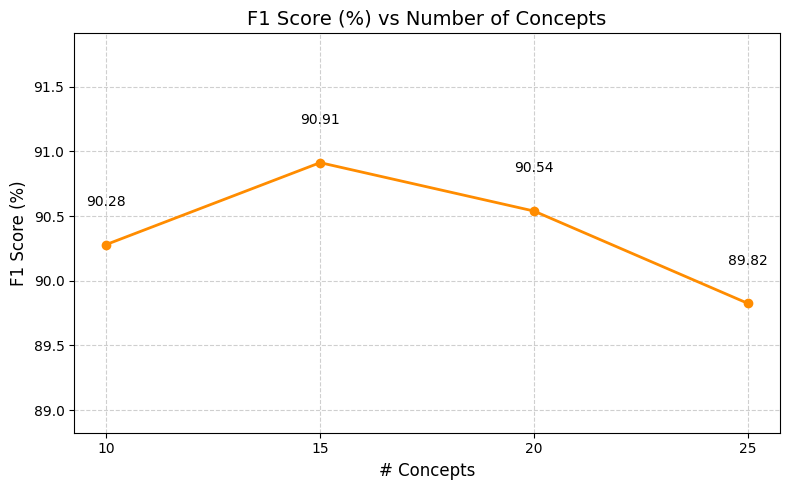

In [7]:
# F1 Weighted scores
# F1 Weighted scores
import matplotlib.pyplot as plt
concept_number = [10, 15, 20, 25]
f1_scores = [0.9027984621982365, 0.9091310385747845, 0.905386614953838, 0.8982453646630972]
f1_percent = [score * 100 for score in f1_scores]

# Plot F1 Weighted
plt.figure(figsize=(8, 5))
plt.plot(concept_number, f1_percent, marker='o', linestyle='-', color='darkorange', linewidth=2)
plt.title('F1 Score (%) vs Number of Concepts', fontsize=14)
plt.xlabel('# Concepts', fontsize=12)
plt.ylabel('F1 Score (%)', fontsize=12)
plt.xticks(concept_number)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(min(f1_percent) - 1, max(f1_percent) + 1)

# Annotate points
for x, y in zip(concept_number, f1_percent):
    plt.text(x, y + 0.3, f"{y:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()
